<a href="https://colab.research.google.com/github/duddet01/Learning_simulations/blob/main/Pi_convergence_MC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***
Std dev calculated using binomial formula for different number of pins throw  i.e number of people × pins , and their relative error are accounted wrt. std which decreased as $n^{-1/2}$
***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

N = 10000   # people
M = 100     # pins per person

pi_list = np.zeros(N)
std = np.zeros(N)

total_hits = 0
total_throws = 0

for i in range(N):

    # generate M points at once (vectorized)
    x = np.random.uniform(-1, 1, M)
    y = np.random.uniform(-1, 1, M)

    hits = (x*x + y*y < 1)   # boolean array

    total_hits += hits.sum()
    total_throws += M

    # estimate π
    p = total_hits / total_throws
    pi_est = 4*p

    # binomial variance
    sigma = 4*np.sqrt(p*(1-p)/total_throws)

    pi_list[i] = pi_est
    std[i] = sigma


pi_list[-1]

np.float64(3.141612)

<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-2072410965.py:8: SyntaxWarning: invalid escape sequence '\p'
  plt.scatter(n[st::k], np.pi-std[st::k], alpha=0.3, label="$\pi$+error envelope")
/tmp/ipython-input-2072410965.py:9: SyntaxWarning: invalid escape sequence '\p'
  plt.scatter(n[st::k], np.pi+std[st::k], alpha=0.3, label="$\pi$-error envelope")


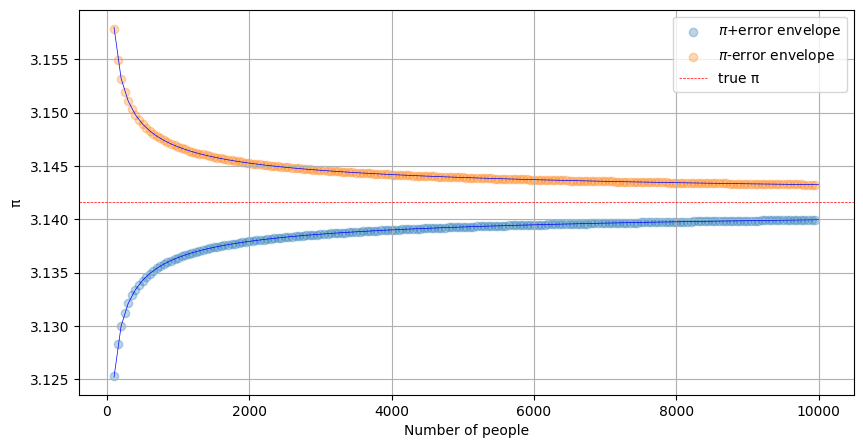

In [ ]:
# plot
n = np.arange(1, N+1)
k=50
st=100
plt.figure(figsize=(10,5))
# plt.scatter(n[st::k], pi_list[st::k], label="$\pi$ estimate",s=0.7)

plt.scatter(n[st::k], np.pi-std[st::k], alpha=0.3, label="$\pi$+error envelope")
plt.scatter(n[st::k], np.pi+std[st::k], alpha=0.3, label="$\pi$-error envelope")
plt.axhline(np.pi, color='red', linestyle='--', label='true π',linewidth=0.5)


ax=np.arange(100,N+1,100)
ay=(ax*M)**(-1/2)*1.64+math.pi
ayy=-(ax*M)**(-1/2)*1.64+math.pi
plt.plot(ax,ay,color='blue',linewidth=0.5)
plt.plot(ax,ayy,color='blue',linewidth=0.5)

plt.ylim()

plt.xlabel("Number of people")
plt.ylabel("π")
plt.grid()
plt.legend()
plt.show()

***
We estimate $\pi$ using blocks of $M$ random points.
After $n$ steps the total number of samples is

$$
T = nM .
$$

For independent sampling, the estimator satisfies

$$
\mathrm{Std}(\hat{\pi}_T)
=
\sqrt{\frac{\pi(4-\pi)}{T}}
=
\frac{\sqrt{\pi(4-\pi)}}{\sqrt{nM}} .
$$

Define the instantaneous fluctuation

$$
\sigma_n = \frac{\sqrt{\pi(4-\pi)}}{\sqrt{nM}} .
$$

---

\subsection*{Extreme--value envelope of many trajectories}

In the simulation we plot $R$ independent running trajectories and
observe the outer envelope

$$
\max_{r=1\ldots R} |\hat{\pi}_r(n)-\pi|.
$$

For Gaussian fluctuations,
the expected maximum of $R$ samples obeys the order--statistics result

$$
\mathbb{E}[\max |X|] \approx \sigma \sqrt{2\ln R}.
$$

Applying this to $\sigma_n$ gives the visible convergence envelope

$$
E(n)
\approx
\sigma_n \sqrt{2\ln R}
=
\frac{\sqrt{\pi(4-\pi)}}{\sqrt{nM}}
\sqrt{2\ln R}.
$$

---

\subsection*{Numerical value for the simulation}

With
$$
M=50,
\qquad
R=150,
$$

$$
\sqrt{\pi(4-\pi)} \approx 1.64,
$$

$$
\sqrt{2\ln(150)} \approx 3.16.
$$

Therefore

$$
E(n)
\approx
\frac{1.64}{\sqrt{50}}\,
\frac{3.16}{\sqrt{n}}
\approx
\frac{0.76}{\sqrt{n}}.
$$

---

$
\boxed{
|\hat{\pi}_n-\pi|
\sim
\frac{0.76}{\sqrt{n}}
}
$

The prefactor $0.76$ arises from


1.geometric variance of the dartboard estimator ($\sqrt{\pi(4-\pi)}$)  
2.block size $M$ reducing noise ($1/\sqrt{M}$)  
3.extreme--value statistics of $R$ trajectories ($\sqrt{2\ln R}$)  


***


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
N = 2000      # number of people
M = 50        # pins per person
runs = 150    # number of independent universes

# storage
trajectories = np.zeros((runs, N))
gaussian_traj=np.zeros(N)
# ----- simulate many universes -----
for r in range(runs):
    total_hits = 0
    total_throws = 0

    for i in range(N):
        x = np.random.uniform(-1,1,M)
        y = np.random.uniform(-1,1,M)

        hits = (x*x + y*y < 1).sum()

        total_hits += hits
        total_throws += M

        trajectories[r,i] = 4*total_hits/total_throws





In [ ]:
# ----- theoretical envelope -----
n = np.arange(1, N+1)
samples = n*M
sigma = np.sqrt(1/samples)*1.64*np.sqrt(2*np.log(runs)) #manual rescaling

upper = np.pi + sigma
lower = np.pi - sigma




(array([ 4., 14.,  9., 23., 31., 18., 26., 17.,  5.,  3.]),
 array([3.02857143, 3.05257143, 3.07657143, 3.10057143, 3.12457143,
        3.14857143, 3.17257143, 3.19657143, 3.22057143, 3.24457143,
        3.26857143]),
 <BarContainer object of 10 artists>)

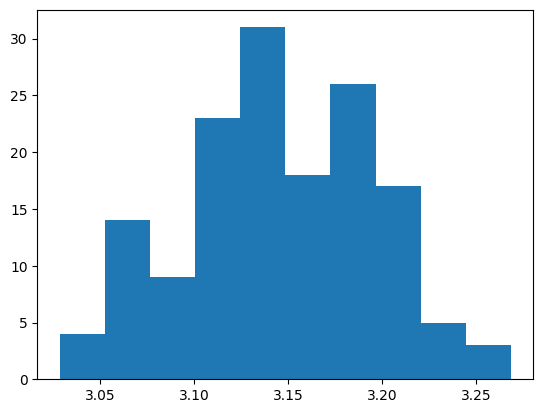

In [ ]:
#plot of particular cross section  here N=20 people showing gaussian like behaviour
plt.hist(trajectories[:,20],10)

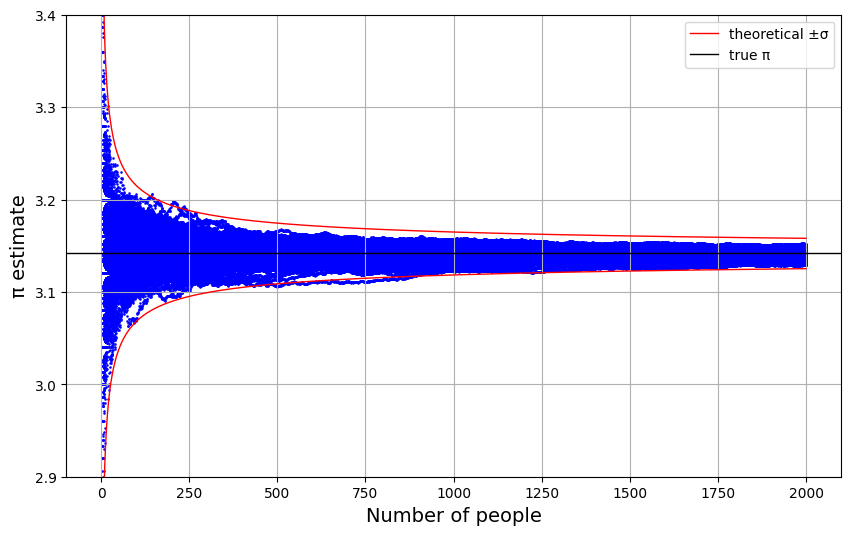

In [ ]:
#Eureka::
#Key rule for convergence----- Averaging over different ensembles with similar statistics to get avg for each increasing pin count and stable distributions.

# ----- plotting -----
plt.figure(figsize=(10,6))

# plot all universes
for r in range(runs):
    plt.scatter(n, trajectories[r], color='blue', s=0.7)

# theoretical cone
plt.plot(n[5:], upper[5:], 'r', linewidth=1, label='theoretical ±σ')
plt.plot(n[5:], lower[5:], 'r', linewidth=1)
plt.ylim(2.9,3.4)
# true value
plt.axhline(np.pi, color='black', linewidth=1, label='true π', linestyle='-')

plt.xlabel("Number of people",fontsize=14)
plt.ylabel("π estimate",fontsize=14)
#plt.title("Monte Carlo π convergence ")
plt.grid()
plt.legend()
plt.show()


***
Similar graph but averaged over different pin_counts simulated across different ensembles to show error convergence following the laws of statistics upto a scaling factor. Here we are measuring the avg error of the stimator , not the divergence from mean value.  

***


 Different ensembles help stabilise the averages and give us an array of different avg values for different pin counts each count thrown by N people. Here my estimator is 4×p where p is the probability of lying inside the circle.  
As a result our variance will be:     
$
\boxed{
\mathrm{Std}(\hat{\pi}_T)=\sqrt\frac{16\,p(1-p)}{N}=\frac{1.64}{\sqrt N}
}
$

where N = pin_count



***
***

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
N = 2000      # number of people
M = 50        # No of differnt pin iterations
pin_count=np.linspace(10,1000,M).astype(int)


def monte_carlo_pi(n):

  total_throws=n
  x = np.random.uniform(-1,1,n)
  y = np.random.uniform(-1,1,n)

  hits = (x*x + y*y < 1).sum()

  return 4*hits/total_throws

# storage
final_pi=[]
final_err=[]
final_std=[]

# ----- simulate many universes -----
for pin in pin_count:
    estimates=[]
    err_pi=[]

    for people in range(N):  #all N people get same no of pins -- but we are taking avgs for different pin counts averaged over N people.

      pi_est=monte_carlo_pi(pin)
      estimates.append(pi_est)
      err_pi.append(np.sqrt((np.pi-pi_est)**2))

    final_pi.append(np.average(estimates))
    final_err.append(np.average(err_pi))
    final_std.append(np.std(estimates))


<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-3534278597.py:3: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(pin_count, np.pi+np.array(final_std), 'o',label='$\pi$+std - upper envelop')
/tmp/ipython-input-3534278597.py:4: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(pin_count, np.pi-np.array(final_std), 'o',label='$\pi$+std - lower envelop')


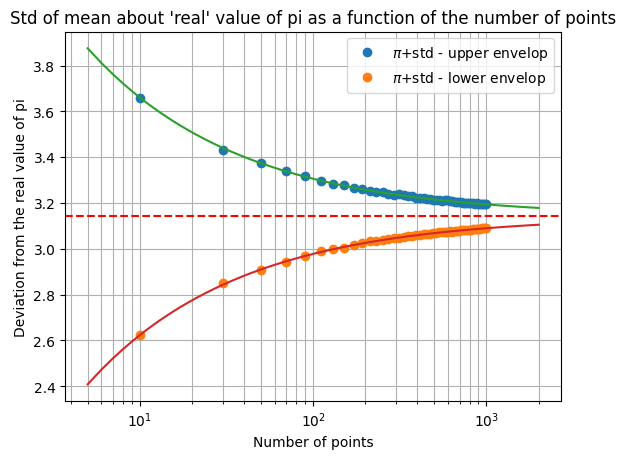

In [ ]:
#To show proper convergence we will show the abs err approching from above and below

plt.plot(pin_count, np.pi+np.array(final_std), 'o',label='$\pi$+std - upper envelop')
plt.plot(pin_count, np.pi-np.array(final_std), 'o',label='$\pi$+std - lower envelop')

# ----- theoretical envelope -----
n = np.arange(5, N+1)
sigma = np.sqrt(1/n)*1.64  #manual rescaling since here var is being captured
upper = np.pi + sigma
lower = np.pi - sigma
plt.plot(n,upper)
plt.plot(n,lower)




plt.axhline(y=np.pi , linestyle='--',color='red')
plt.xscale('log')
plt.xlabel('Number of points')
plt.ylabel('Deviation from the real value of pi')
plt.title("Std of mean about 'real' value of pi as a function of the number of points")
plt.grid(True,which='both')
plt.legend()
plt.show()